# <b>COVID-19 Forecasting & Analytics Platform</b>
## <b>Step 3: EDA Summary</b>
### <b>Objective</b>

The objective of this exploratory data analysis is to understand the global COVID-19 dataset, identify important trends, detect data quality issues, and discover features that can improve the performance of forecasting models.

### <b>1. Import the libraries</b>

In [1]:
# Import the Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

pd.set_option("display.max_columns", None)

### <b>2. Dataset Overview</b>
#### <b>Insight</b>
The dataset contains over 400,000 observations collected from multiple countries and regions worldwide.
Data includes information related to COVID-19 cases, deaths, vaccinations, population, and temporal variables.
The large volume of data makes it suitable for both statistical analysis and machine learning applications.

In [2]:
# Load the dataset
df = pd.read_csv("../data/processed/covid_ML_dataset.csv")

print(df.shape)

(402910, 18)


In [3]:
# Dataset information
print(f"Dataset Information:\n {df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402910 entries, 0 to 402909
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   iso_code           402910 non-null  object 
 1   continent          402910 non-null  object 
 2   location           402910 non-null  object 
 3   date               402910 non-null  object 
 4   total_cases        402910 non-null  float64
 5   new_cases          402910 non-null  float64
 6   total_deaths       402910 non-null  float64
 7   new_deaths         402910 non-null  float64
 8   people_vaccinated  402910 non-null  float64
 9   population         402910 non-null  int64  
 10  mortality_rate     402910 non-null  float64
 11  vaccination_rate   402910 non-null  float64
 12  cases_7d_avg       402910 non-null  float64
 13  cases_14d_avg      402910 non-null  float64
 14  year               402910 non-null  int64  
 15  month              402910 non-null  int64  
 16  da

In [4]:
# Statistical Summary
print(f"\nDataset description: \n {df.describe().T}")


Dataset description: 
                       count          mean           std     min  \
total_cases        402910.0  1.776320e+06  7.753085e+06     0.0   
new_cases          402910.0  1.925827e+03  8.447995e+04     0.0   
total_deaths       402910.0  1.988027e+04  8.153673e+04     0.0   
new_deaths         402910.0  1.752498e+01  3.100215e+02     0.0   
people_vaccinated  402910.0  5.622976e+06  5.419291e+07     0.0   
population         402910.0  3.338239e+07  1.348128e+08    47.0   
mortality_rate     402910.0  1.024498e+01  8.221318e+02     0.0   
vaccination_rate   402910.0  8.672726e+00  2.302309e+01     0.0   
cases_7d_avg       402910.0  1.925743e+03  3.188061e+04     0.0   
cases_14d_avg      402910.0  1.925683e+03  2.963154e+04     0.0   
year               402910.0  2.021820e+03  1.331256e+00  2020.0   
month              402910.0  6.226189e+00  3.394792e+00     1.0   
day                402910.0  1.572715e+01  8.799195e+00     1.0   
weekday            402910.0  3.001718e

#### <b>Key Observation</b>

The dataset spans multiple years and countries, providing sufficient historical information for time-series forecasting and trend analysis.

### <b> 3. Missing Value Analysis</b>
Insight
Several original variables contained missing values due to differences in reporting standards across countries.
Missing numerical values were replaced with zeros where appropriate.
Only relevant columns required for forecasting were retained.

In [5]:
# Finding Null Values
df.isnull().sum()

iso_code             0
continent            0
location             0
date                 0
total_cases          0
new_cases            0
total_deaths         0
new_deaths           0
people_vaccinated    0
population           0
mortality_rate       0
vaccination_rate     0
cases_7d_avg         0
cases_14d_avg        0
year                 0
month                0
day                  0
weekday              0
dtype: int64

### <b>4. Top Countries by Total Cases</b>
#### <b>Insight</b>
A small number of countries contribute disproportionately to global COVID-19 cases.
Countries such as the United States, India, and Brazil consistently appear among the highest case counts.

In [6]:
# Top Countries by Total cases
latest = df.sort_values('date').groupby('location').tail(1)

top_cases = (
    latest[['location', 'total_cases']].sort_values(
        'total_cases', ascending=False
    ).head(10)
)

In [7]:
fig = px.bar(
    top_cases,
    x='location',
    y='total_cases',
    title="Top 10 Countries by Total Cases"
)

fig.show()

#### <b> Key Observation</b>

The distribution of COVID-19 cases is highly uneven across countries, indicating strong geographical variation in pandemic impact.

#### <b>Business Interpretation</b>

Governments and healthcare agencies in highly affected countries require more accurate forecasting models to support resource planning.

### <b>5. Vaccination Analysis</b>
#### <b>Insight</b>
Vaccination rates vary significantly across countries.
Developed countries generally achieved higher vaccination coverage compared to developing nations.

In [8]:
# Top Countries by Vaccination Rate
top_vax = (
    latest[['location', 'vaccination_rate']].sort_values(
        'vaccination_rate', ascending=False
    ).head(10)
)

In [9]:
fig = px.bar(
    top_vax,
    x='location',
    y='vaccination_rate',
    title="Top Vaccinated Countries"
)

fig.show()

#### <b> Key Observation</b>

Vaccination coverage may influence future case trends and therefore represents an important predictive feature.

### <b>6. Global COVID Trend Analysis</b>
#### <b>Insight</b>
Global COVID-19 cases exhibit multiple waves rather than a steady trend.
Significant peaks correspond to major outbreaks and the emergence of variants.

In [10]:
# Global Covid Trend
global_daily = (
    df.groupby("date")['new_cases'].sum().reset_index()
)

In [11]:
fig = px.line(
    global_daily,
    x='date',
    y='new_cases',
    title="Global Daily Cases"
)

fig.show()

#### <b>Key Observation</b>

The data contains strong temporal patterns and seasonality.

### <b>7. India Trend Analysis</b>
#### <b>Insight</b>
India experienced multiple distinct infection waves.
Sharp increases and decreases in cases demonstrate strong temporal dependency.

In [12]:
# India Trend
india = df[df['location'] == 'India']

In [13]:
fig = px.line(
    india,
    x='date',
    y='new_cases',
    title="India Daily Cases"
)

fig.show()

#### <b> Key Observation</b>

Historical case counts strongly influence future case counts.

### <b>8. Correlation Heatmap</b>
#### <b>Insight</b>

The correlation analysis revealed relationships between engineered features and the target variable `new_cases`.

In [14]:
# Correlation Analysis
features = ['total_cases', 
            'total_deaths', 
            'people_vaccinated',
            'population',
            'mortality_rate',
            'vaccination_rate',
            'cases_7d_avg',
            'cases_14d_avg',
            'new_cases'
        ]

corr= df[features].corr()

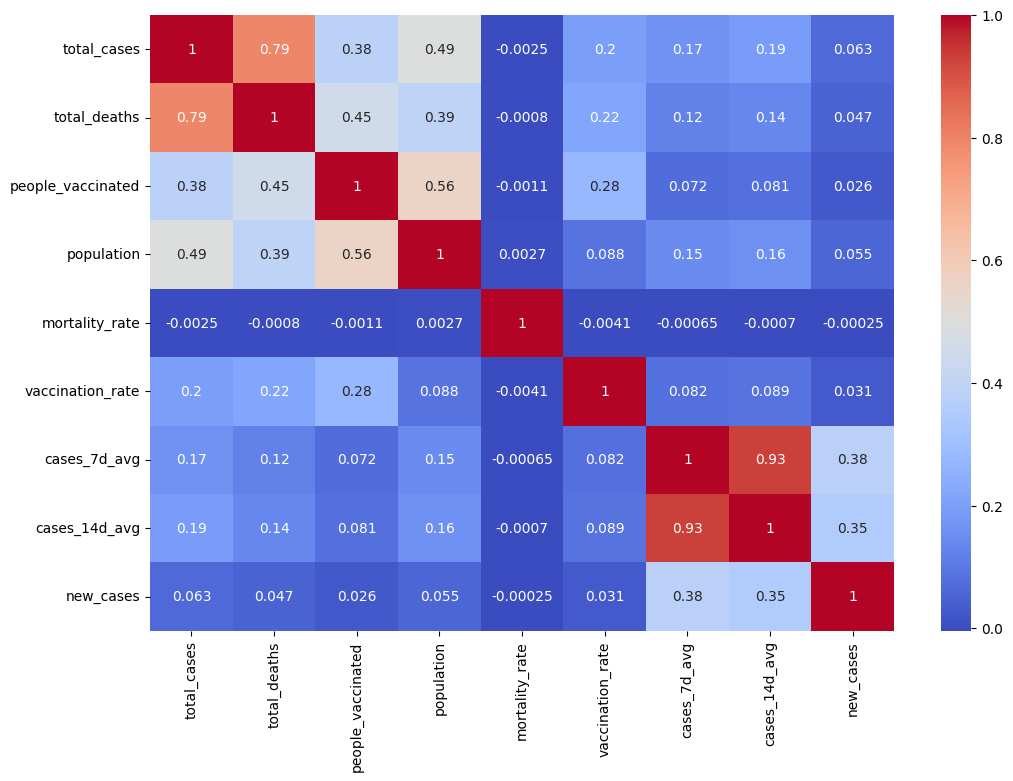

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

#### <b>Key Findings</b>
- Rolling averages showed strong positive correlation with daily cases.
- Vaccination and mortality-related features exhibited weaker correlations.
- Historical case-based features appear to be the most informative predictors.

### <b>9.Distribution of Daily Cases</b>
#### <b>Insight</b>

The target variable (new_cases) is highly right-skewed.

In [16]:
(df['new_cases'] == 0).mean()

df['new_cases'].describe(percentiles=[0.5,0.75,0.9,0.95,0.99,0.999])

count    4.029100e+05
mean     1.925827e+03
std      8.447995e+04
min      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      0.000000e+00
95%      3.425500e+02
99%      2.146564e+04
99.9%    3.401828e+05
max      4.047548e+07
Name: new_cases, dtype: float64

##### <b>Evidence: </b>
<b> Statistical summary:</b>
- 50th Percentile = 0
- 75th Percentile = 0
- 90th Percentile = 0
- 95th Percentile = 342
- 99th Percentile = 21,465
- Maximum = 40,475,480

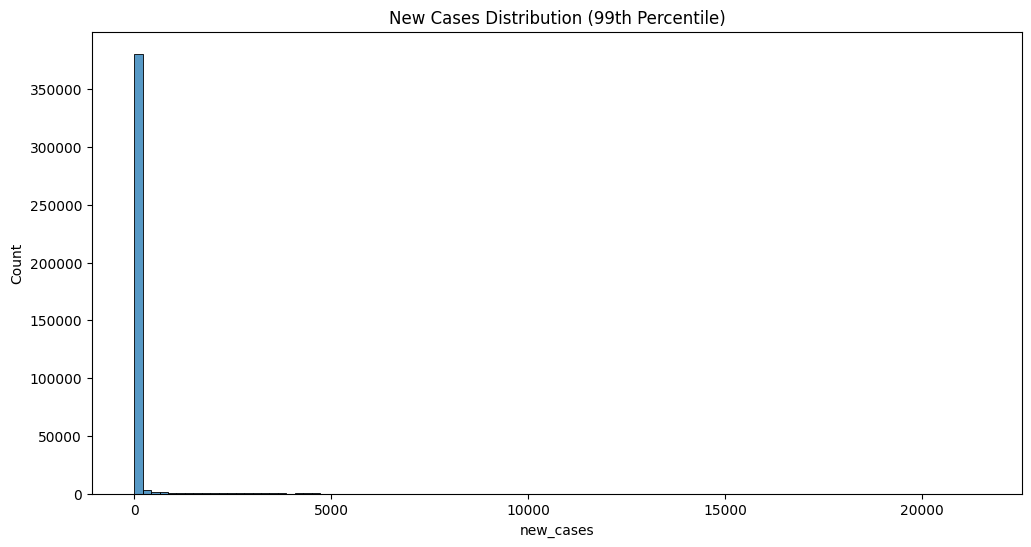

In [17]:
# Distribution of target Variable
upper = df['new_cases'].quantile(0.99)

filtered = df[
    df['new_cases'] <= upper
]

plt.figure(figsize=(12,6))

sns.histplot(
    filtered['new_cases'],
    bins=100
)

plt.title("New Cases Distribution (99th Percentile)")
plt.show()

#### <b>Key Observation</b>

Most observations contain very low or zero case counts, while a small number of observations contain extremely large values.

### <b>10. Log Transformation Analysis</b>
#### <b>Insight</b>

A logarithmic transformation was applied to reduce skewness.

In [18]:
# Log Transforation Check
df['log_new_cases'] = np.log1p(df['new_cases'])

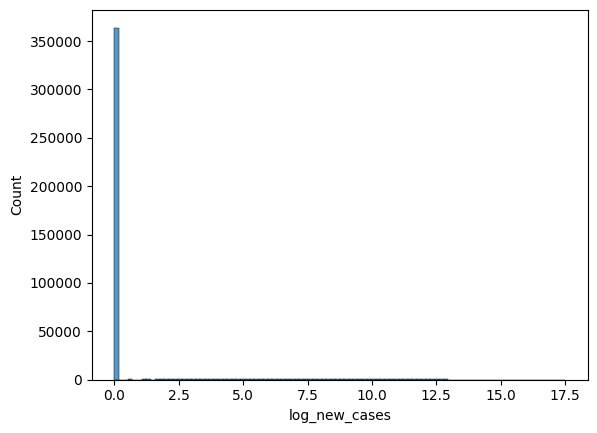

In [19]:
sns.histplot(
    df['log_new_cases'], bins=100
)
plt.show()

#### <b>Key Observation</b>

Although the transformation reduced the influence of extreme outliers, a large concentration of zero values remained.

### <b>EDA Conclusion</b>
Country-specific forecasting is more appropriate than global forecasting because the target distribution varies significantly across countries.
#### Key Findings
- The dataset contains more than 400,000 observations across multiple countries.
- COVID-19 trends exhibit strong temporal patterns and multiple outbreak waves.
- Rolling averages are highly informative predictors of future case counts.
- Vaccination and mortality metrics provide additional contextual information.
- The target variable is highly skewed and contains a large number of zero values.
- Global forecasting is likely to produce poor results due to heterogeneous reporting behavior.
- Country-level forecasting provides a more realistic and interpretable machine learning problem.

#### <b>Decision for Modeling</b>

Based on the EDA findings, the forecasting model will focus on India-specific COVID-19 case prediction using:

- Lag Features
- Rolling Averages
- Vaccination Rate
- Mortality Rate
- Temporal Features

This approach reduces noise, improves model interpretability, and aligns better with real-world forecasting objectives.